In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Input

In [5]:
df = pd.read_csv("../data/featured_personal_loan.csv")

In [6]:
X = df.drop("Personal.Loan", axis=1)
y = df["Personal.Loan"]
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=1/3,
    random_state=42,
    stratify=y_temp
)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

# Build Model Start 

In [8]:
model = Sequential([
    Input(shape=(11,)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

In [9]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.1)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

# Train Model Start

In [11]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9523 - loss: 0.1453 - val_accuracy: 0.9700 - val_loss: 0.0796
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9643 - loss: 0.1074 - val_accuracy: 0.9620 - val_loss: 0.0896
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9674 - loss: 0.0973 - val_accuracy: 0.9730 - val_loss: 0.0698
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9677 - loss: 0.0876 - val_accuracy: 0.9870 - val_loss: 0.0458
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9717 - loss: 0.0855 - val_accuracy: 0.9700 - val_loss: 0.0827
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9711 - loss: 0.0858 - val_accuracy: 0.9790 - val_loss: 0.0633
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9760 - loss: 0.0751 - val_accuracy: 0.9700 - val_loss: 0.0920
Epoch 8/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9700 - loss: 0.0792 - val_accuracy: 0

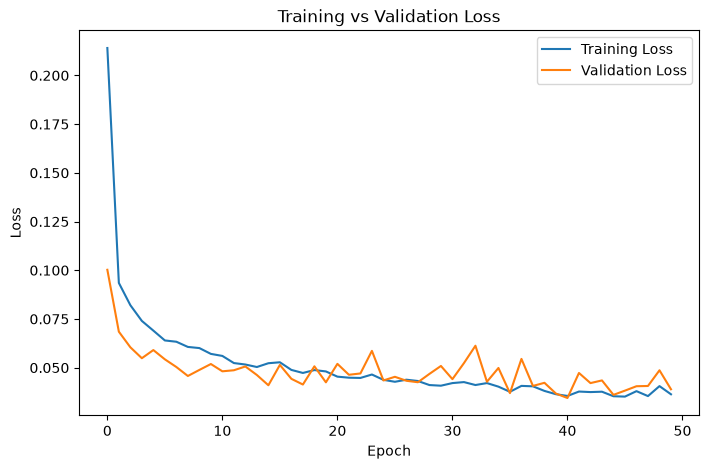

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

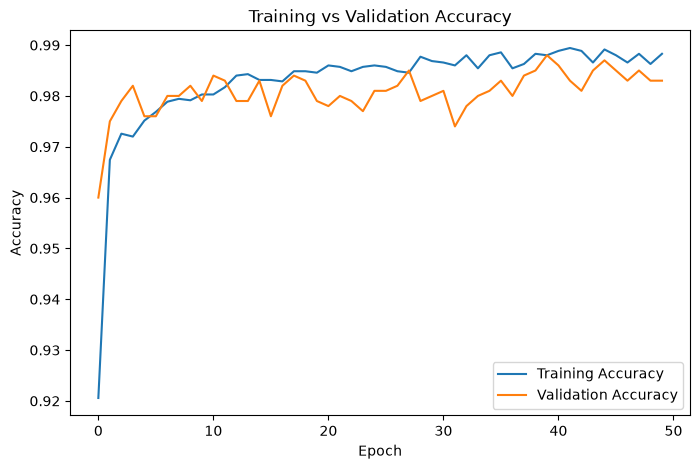

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [24]:
print("Final Training Accuracy:", history.history["accuracy"][-1])
print("Final Validation Accuracy:", history.history["val_accuracy"][-1])

print("Final Training Loss:", history.history["loss"][-1])
print("Final Validation Loss:", history.history["val_loss"][-1])

Final Training Accuracy: 0.9882857203483582
Final Validation Accuracy: 0.9829999804496765
Final Training Loss: 0.036347098648548126
Final Validation Loss: 0.038919512182474136


# Experiment 2

In [25]:
model = Sequential([
    Input(shape=(11,)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

In [26]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [27]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9234 - loss: 0.2181 - val_accuracy: 0.9570 - val_loss: 0.1127
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9637 - loss: 0.1046 - val_accuracy: 0.9710 - val_loss: 0.0753
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9697 - loss: 0.0859 - val_accuracy: 0.9800 - val_loss: 0.0603
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9734 - loss: 0.0741 - val_accuracy: 0.9860 - val_loss: 0.0519
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9766 - loss: 0.0679 - val_accuracy: 0.9790 - val_loss: 0.0567
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9786 - loss: 0.0660 - val_accuracy: 0.9820 - val_loss: 0.0504
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9766 - loss: 0.0640 - val_accuracy: 0.9810 - val_loss: 0.0458
Epoch 8/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9774 - loss: 0.0611 - val_accurac

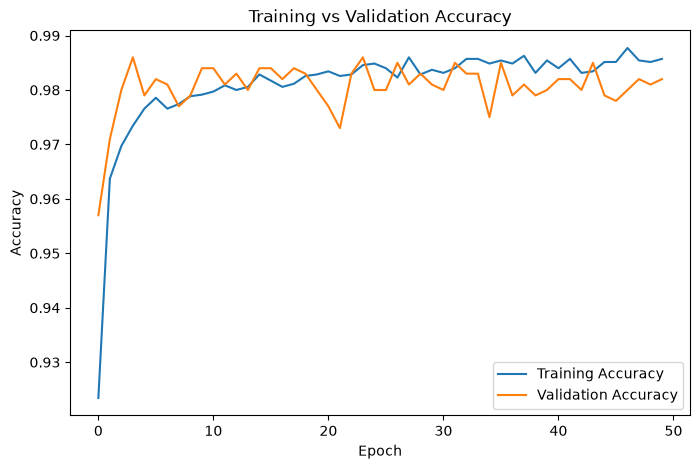

In [28]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

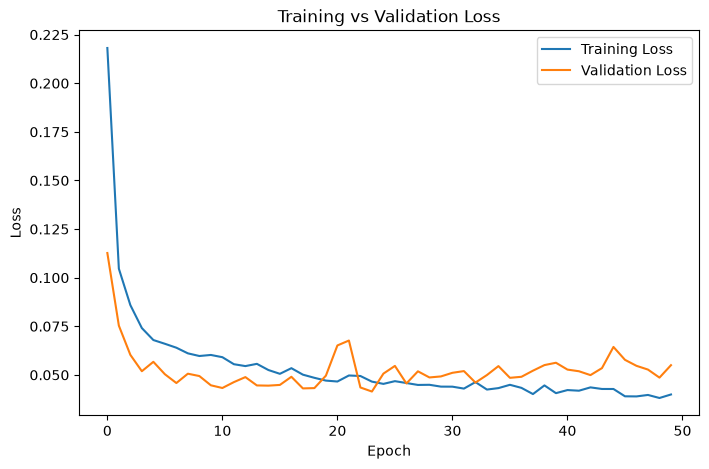

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [30]:
print("Final Training Accuracy:", history.history["accuracy"][-1])
print("Final Validation Accuracy:", history.history["val_accuracy"][-1])

print("Final Training Loss:", history.history["loss"][-1])
print("Final Validation Loss:", history.history["val_loss"][-1])

Final Training Accuracy: 0.9857142567634583
Final Validation Accuracy: 0.9819999933242798
Final Training Loss: 0.03993871808052063
Final Validation Loss: 0.05500989779829979


# Experiment 3

In [31]:
model = Sequential([
    Input(shape=(11,)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

In [32]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [33]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9203 - loss: 0.1933 - val_accuracy: 0.9660 - val_loss: 0.0879
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9677 - loss: 0.0921 - val_accuracy: 0.9790 - val_loss: 0.0639
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9726 - loss: 0.0757 - val_accuracy: 0.9800 - val_loss: 0.0553
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9763 - loss: 0.0684 - val_accuracy: 0.9750 - val_loss: 0.0595
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9783 - loss: 0.0634 - val_accuracy: 0.9780 - val_loss: 0.0534
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9783 - loss: 0.0612 - val_accuracy: 0.9810 - val_loss: 0.0476
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9814 - loss: 0.0563 - val_accuracy: 0.9850 - val_loss: 0.0454
Epoch 8/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9834 - loss: 0.0569 - val_accuracy: 

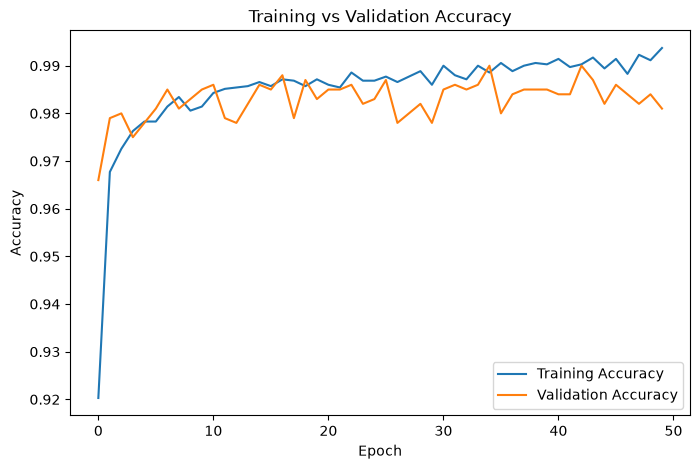

In [34]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

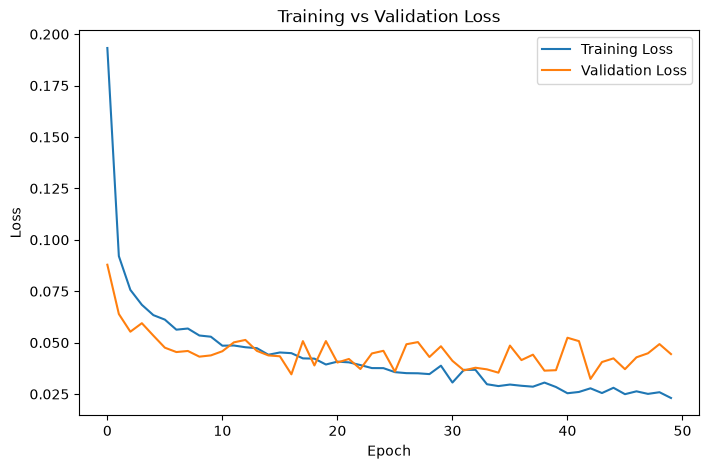

In [35]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [36]:
print("Final Training Accuracy:", history.history["accuracy"][-1])
print("Final Validation Accuracy:", history.history["val_accuracy"][-1])

print("Final Training Loss:", history.history["loss"][-1])
print("Final Validation Loss:", history.history["val_loss"][-1])

Final Training Accuracy: 0.9937142729759216
Final Validation Accuracy: 0.9810000061988831
Final Training Loss: 0.023085540160536766
Final Validation Loss: 0.04443724825978279


# Experiment 4

In [38]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),   
    Dense(64, activation='relu'),       
    Dense(32, activation='relu'),       
    Dense(1, activation='sigmoid')       
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9320 - loss: 0.1504 - val_accuracy: 0.9280 - val_loss: 0.1461
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9306 - loss: 0.1501 - val_accuracy: 0.9410 - val_loss: 0.1286
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9311 - loss: 0.1505 - val_accuracy: 0.9410 - val_loss: 0.1309
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9369 - loss: 0.1426 - val_accuracy: 0.9420 - val_loss: 0.1244
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9420 - loss: 0.1412 - val_accuracy: 0.9500 - val_loss: 0.1194
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9357 - loss: 0.1503 - val_accuracy: 0.9450 - val_loss: 0.1218
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9406 - loss: 0.1405 - val_accuracy: 0.9440 - val_loss: 0.1234
Epoch 8/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9377 - loss: 0.1413 - val_accuracy: 0.

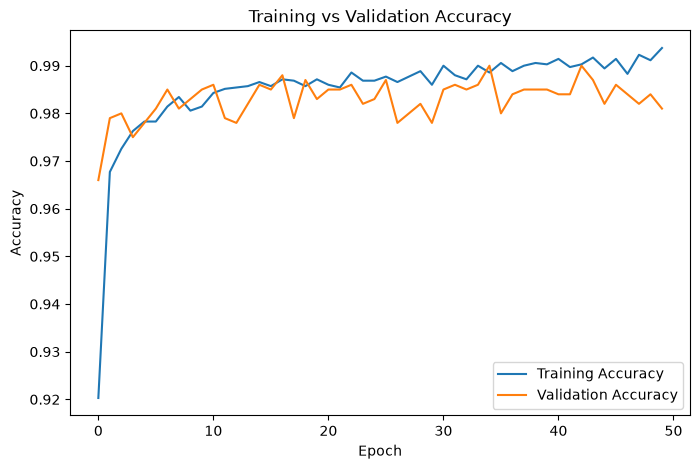

In [39]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

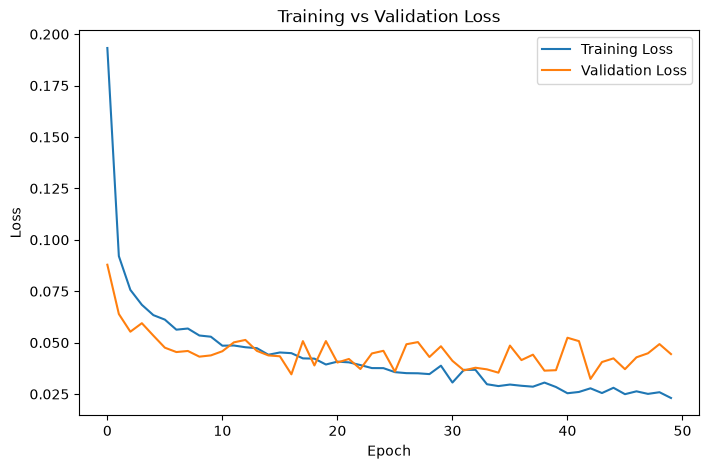

In [40]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [51]:
print("Final Training Accuracy:", history.history["accuracy"][-1])
print("Final Validation Accuracy:", history.history["val_accuracy"][-1])

print("Final Training Loss:", history.history["loss"][-1])
print("Final Validation Loss:", history.history["val_loss"][-1])

Final Training Accuracy: 0.9614285826683044
Final Validation Accuracy: 0.9760000109672546
Final Training Loss: 0.09925323724746704
Final Validation Loss: 0.06674265116453171


# Experiment no 5 

In [48]:
from tensorflow.keras.layers import Dropout
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    
    Dense(64, activation='relu'),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8083 - loss: 2.1564 - val_accuracy: 0.9040 - val_loss: 0.5157
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8531 - loss: 0.8522 - val_accuracy: 0.8880 - val_loss: 0.3046
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8654 - loss: 0.5096 - val_accuracy: 0.8990 - val_loss: 0.2947
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8843 - loss: 0.3536 - val_accuracy: 0.9050 - val_loss: 0.2946
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8929 - loss: 0.3234 - val_accuracy: 0.9040 - val_loss: 0.3008
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8946 - loss: 0.3225 - val_accuracy: 0.8980 - val_loss: 0.2630
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8983 - loss: 0.2820 - val_accuracy: 0.9040 - val_loss: 0.2606
Epoch 8/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8991 - loss: 0.2649 - val_accuracy:

In [49]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

print("Final Training Accuracy:", train_acc)
print("Final Validation Accuracy:", val_acc)
print("Final Training Loss:", train_loss)
print("Final Validation Loss:", val_loss)

Final Training Accuracy: 0.9408571720123291
Final Validation Accuracy: 0.9390000104904175
Final Training Loss: 0.12793990969657898
Final Validation Loss: 0.12906907498836517
